# Synthetic-100: current MiSTIC configuration vs sklearn references (10 seeds)

This notebook compares the current best forward-knee MiSTIC configuration
(`rank_weight=0.90`) with three practical sklearn references and the known-signal
oracle. Every fit uses the same 375 training observations and the same untouched
125-observation blind set. Seeds change only the inner resampling/model-building
process, not the blind observations.

The practical references are: all 100 features; linear-SVM RFE to 20 features;
and an RBF-SVM trained on the top unified-ranked features, limited to the MiSTIC
knee count for that seed. The oracle uses the 20 known signal features and is a
best-case reference, not a deployable feature-selection method.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES, n_features=N_FEATURES,
    n_informative=N_INFORMATIVE, n_redundant=N_REDUNDANT,
    n_repeated=0, n_classes=2, weights=[0.55, 0.45],
    class_sep=1.0, flip_y=0.03, shuffle=False, random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
NUM_MODELS = 5
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED,
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")


Training rows: 375; fixed blind rows: 125


In [3]:
def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def fit_sklearn_reference(features, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )
    return search.fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled, np.asarray(y_train), num_feature_medoids=20,
        ensemble_validation_size=0.0,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=NUM_MODELS, validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"), splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [paramSet(model={"C": c}, kernel={"gamma": g})
            for c in C_VALUES for g in GAMMA_VALUES]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn_reference(features, seed)
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "num_features": len(features), "signal_recall": recall,
        "signal_precision": precision, "cv_best_score": model.best_score_,
        "best_C": model.best_params_["svc__C"],
        "best_gamma": model.best_params_["svc__gamma"],
        **metric_row(y_blind, model.predict(X_blind.iloc[:, features]),
                     model.decision_function(X_blind.iloc[:, features])),
    }


## Execute the paired 10-seed comparison

RFE is fitted only on the training data. Since its selector is deterministic,
its selected feature set is constant here; the seed still changes the four-fold
CV partitions used to tune the final RBF-SVM. MiSTIC’s unified reference is
seed-specific and uses no blind-set information.


In [4]:
rows = []
all_features = np.arange(N_FEATURES)
oracle_features = np.arange(N_INFORMATIVE + N_REDUNDANT)

selector_scaler = StandardScaler().fit(X_train)
selector = RFE(
    estimator=SVC(kernel="linear", C=1.0, class_weight="balanced"),
    n_features_to_select=RFE_FEATURE_COUNT, step=0.1,
).fit(selector_scaler.transform(X_train), y_train)
rfe_features = np.flatnonzero(selector.support_)

for seed in INNER_SEEDS:
    started = time.perf_counter()
    scaler, ensemble, knee_count = fit_mistic(seed)
    X_blind_scaled = scaler.transform(X_blind)
    unified_features = ranked_unified_features(ensemble, knee_count)
    top20 = ranked_unified_features(ensemble, 20)
    recall, precision = recovery(top20)
    selected_counts = [len(f) for f in ensemble.features]
    rows.append({
        "seed": seed, "method": "MiSTIC forward-knee (weight=0.90)",
        "num_models": NUM_MODELS, "num_features": np.mean(selected_counts),
        "signal_recall": recall, "signal_precision": precision,
        "cv_best_score": np.nan, "best_C": np.nan, "best_gamma": np.nan,
        **metric_row(y_blind, ensemble.predict(X_blind_scaled),
                     ensemble.decision_function(X_blind_scaled)),
    })
    rows.append(sklearn_row("sklearn: knee-ranked unified", unified_features, seed))
    rows.append(sklearn_row("sklearn: all 100 features", all_features, seed))
    rows.append(sklearn_row("sklearn: linear-SVM RFE (20)", rfe_features, seed))
    rows.append(sklearn_row("sklearn oracle: known signal (20)", oracle_features, seed))
    print(f"seed {seed} complete ({time.perf_counter() - started:.1f}s), knee={knee_count}")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_rank09_vs_sklearn_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.698


Number of Features: 10, Score: 0.796


Number of Features: 19, Score: 0.781


Number of Features: 20, Score: 0.782
Number of Features: 100, Score: 0.768


seed 0 complete (11.3s), knee=10


...

Number of Features: 10, Score: 0.774


Number of Features: 19, Score: 0.751


Number of Features: 20, Score: 0.750
Number of Features: 100, Score: 0.729


seed 9 complete (21.2s), knee=10


,seed,method,num_models,num_features,signal_recall,signal_precision,cv_best_score,best_C,best_gamma,roc_auc,f1,balanced_accuracy,accuracy
0,0,MiSTIC forward-knee (weight=0.90),5,10.0,0.60,0.750000,NaN,NaN,NaN,0.971273,0.894737,0.904633,0.904
1,0,sklearn: knee-ranked unified,1,10.0,0.45,0.900000,0.905500,4.0,0.031250,0.962474,0.888889,0.899068,0.896
2,0,sklearn: all 100 features,1,100.0,1.00,0.200000,0.841424,4.0,0.007812,0.827122,0.736842,0.759058,0.760
3,0,sklearn: linear-SVM RFE (20),1,20.0,0.40,0.400000,0.890856,1.0,0.031250,0.875259,0.787402,0.794255,0.784
4,0,sklearn oracle: known signal (20),1,20.0,1.00,1.000000,0.962652,4.0,0.031250,0.972308,0.927273,0.933618,0.936
5,1,MiSTIC forward-knee (weight=0.90),5,10.0,0.60,0.800000,NaN,NaN,NaN,0.966615,0.886957,0.897386,0.896
6,1,sklearn: knee-ranked unified,1,10.0,0.50,1.000000,0.906667,4.0,0.031250,0.976190,0.915254,0.924172,0.920
7,1,sklearn: all 100 features,1,100.0,1.00,0.200000,0.838246,4.0,0.031250,0.845497,0.388889,0.610507,0.648
8,1,sklearn: linear-SVM RFE (20),1,20.0,0.40,0.400000,0.893660,4.0,0.031250,0.894151,0.774194,0.783644,0.776
9,1,sklearn oracle: known signal (20),1,20.0,1.00,1.000000,0.946728,4.0,0.031250,0.972308,0.927273,0.933618,0.936


In [5]:
metrics = ["roc_auc", "f1", "balanced_accuracy", "accuracy",
           "num_features", "signal_recall", "signal_precision"]
summary = results.groupby("method")[metrics].agg(["mean", "std"])
summary.round(4)


roc_auc              f1          \
                                     mean     std    mean     std   
method                                                              
MiSTIC forward-knee (weight=0.90)  0.9685  0.0039  0.8902  0.0078   
sklearn oracle: known signal (20)  0.9723  0.0000  0.9273  0.0000   
sklearn: all 100 features          0.8345  0.0095  0.5977  0.1797   
sklearn: knee-ranked unified       0.9693  0.0077  0.9025  0.0132   
sklearn: linear-SVM RFE (20)       0.8904  0.0080  0.7768  0.0056   

                                  balanced_accuracy         accuracy          \
                                               mean     std     mean     std   
method                                                                         
MiSTIC forward-knee (weight=0.90)            0.9005  0.0072   0.8992  0.0067   
sklearn oracle: known signal (20)            0.9336  0.0000   0.9360  0.0000   
sklearn: all 100 features                    0.6996  0.0767   0.7152  0.0578   
sklearn: knee-ranked unified                 0.9120  0.0125   0.9080  0.0126   
sklearn: linear-SVM RFE (20)                 0.7858  0.0045   0.7776  0.0034   

                                  num_features      signal_recall          \
                                          mean  std          mean     std   
method                                                                      
MiSTIC forward-knee (weight=0.90)         10.0  0.0         0.650  0.0408   
sklearn oracle: known signal (20)         20.0  0.0         1.000  0.0000   
sklearn: all 100 features                100.0  0.0         1.000  0.0000   
sklearn: knee-ranked unified              10.0  0.0         0.475  0.0264   
sklearn: linear-SVM RFE (20)              20.0  0.0         0.400  0.0000   

                                  signal_precision          
                                              mean     std  
method                                                      
MiSTIC forward-knee (weight=0.90)           0.8105  0.0707  
sklearn oracle: known signal (20)           1.0000  0.0000  
sklearn: all 100 features                   0.2000  0.0000  
sklearn: knee-ranked unified                0.9500  0.0527  
sklearn: linear-SVM RFE (20)                0.4000  0.0000

In [6]:
mistic_auc = results.query("method == 'MiSTIC forward-knee (weight=0.90)'").set_index("seed")["roc_auc"]
paired_rows = []
for method, group in results.groupby("method"):
    if method.startswith("MiSTIC"):
        continue
    delta = mistic_auc - group.set_index("seed")["roc_auc"]
    paired_rows.append({
        "reference": method,
        "mean_auc_difference_mistic_minus_reference": delta.mean(),
        "std_auc_difference": delta.std(ddof=1),
        "mistic_wins": int((delta > 0).sum()),
        "ties": int((delta == 0).sum()),
        "reference_wins": int((delta < 0).sum()),
    })
paired = pd.DataFrame(paired_rows).sort_values("mean_auc_difference_mistic_minus_reference", ascending=False)
paired.round(4)


,reference,mean_auc_difference_mistic_minus_reference,std_auc_difference,mistic_wins,ties,reference_wins
1,sklearn: all 100 features,0.1340,0.0101,10,0,0
3,sklearn: linear-SVM RFE (20),0.0781,0.0099,10,0,0
2,sklearn: knee-ranked unified,-0.0008,0.0092,5,0,5
0,sklearn oracle: known signal (20),-0.0038,0.0039,1,0,9


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_60231/1604495331.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data, y="method", x="roc_auc", order=order,


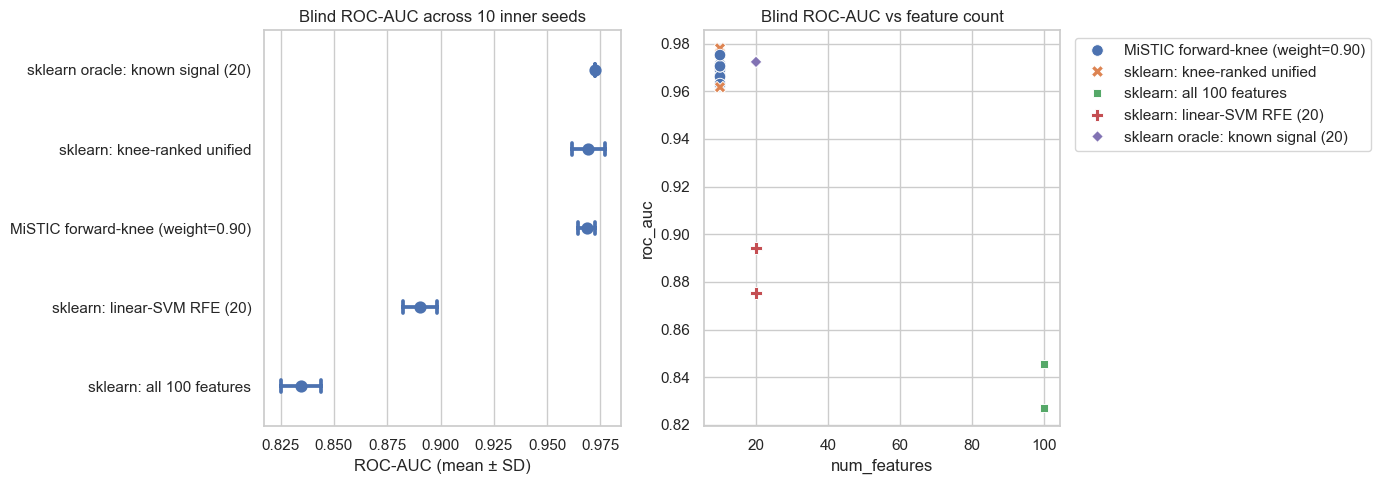

In [7]:
plot_data = results.copy()
order = results.groupby("method")["roc_auc"].mean().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.pointplot(data=plot_data, y="method", x="roc_auc", order=order,
              errorbar="sd", join=False, capsize=0.15, ax=axes[0])
axes[0].set_title("Blind ROC-AUC across 10 inner seeds")
axes[0].set_xlabel("ROC-AUC (mean ± SD)")
axes[0].set_ylabel("")
sns.scatterplot(data=plot_data, x="num_features", y="roc_auc",
                hue="method", style="method", s=70, ax=axes[1])
axes[1].set_title("Blind ROC-AUC vs feature count")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_rank09_vs_sklearn_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation

The paired differences above are descriptive because all ten model-building
seeds are evaluated on the same blind observations. They measure sensitivity
to inner resampling and selection, not uncertainty over independent test sets.
The oracle is included only to show the remaining cost of imperfect feature
recovery.
